<a href="https://colab.research.google.com/github/HieuStudyingCS/California-housing-price-prediction/blob/main/Covariance_matrix_adaptation_Evolutionary_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Covariance Matrix Adaptation - Evolutionary Strategy
Đầu tiên đi qua phần lý thuyết về CMA-ES

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display, Image

# Preliminaries
CMA-ES stands for Covariance Matrix Adaptation - Evolutionary Strategy. The CMA-ES is a stochastic, or randomized, method for real-parameter (continuous domain) optimization of non-linear, non-convex functions

# Eigendecomposition of a Positive Definite Matrix

A symmetric, positive definite matrix $C \in \mathcal{R}^{n \times n}$, is characterized in that for all $\mathbf{x} \in \mathcal{R}^n \backslash \{\mathbf{0}\}$ holds $\mathbf{x}^TC\mathbf{x} > 0$. The matrix $C$ has an orthornormal basis of eigenvectors, $\mathbf{B} = [\mathbf{b_1}, \mathbf{b_2}, \dots, \mathbf{b_n}]$ with corresponding eigenvalues, $d_1^2, d_2^2, \dots, d_n^2 > 0$

$$
C\mathbf{b_i} = d_i^2\mathbf{b_i}
$$

An basis of eigenvectors is practical, because for any $\mathbf{v} \in \mathcal{R}^n$ we can find coefficients $\alpha_i$, such that $\mathbf{v} = \sum_i \alpha_i\mathbf{b_i}$, and then we have

$$
C\mathbf{v} = \sum_id_i^2\alpha_i\mathbf{b_i}
$$

And then we have

$$
C = BD^2B^T \tag{1}
$$

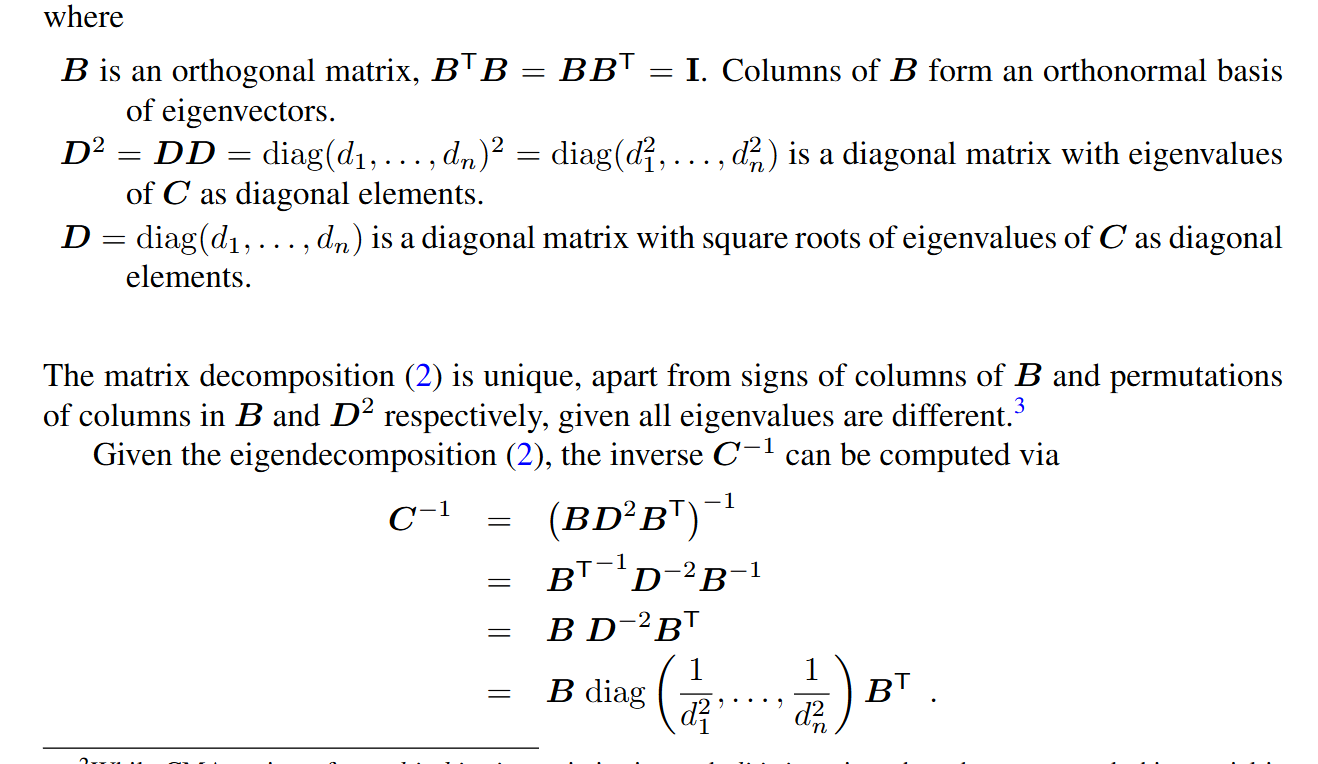

In [7]:
file_path = '/content/drive/MyDrive/Hình cho CMA-ES/assets/1.png'
display(Image(filename=file_path, width=600))

Tới đây thì tôi có thắc mắc vì sao tác giả lại định nghĩa ma trận $D$ như vậy? Nên sẽ được giải thích sau sau khi đi sâu vào giải thích thuật toán cma-es

Từ (1) thì ta có được

$$
C^{\frac{1}{2}} = BDB^T
$$

and therefore

$$
C^{-\frac{1}{2}} = BD^{-1}B^T = B \operatorname{diag}(\frac{1}{d_1}, \frac{1}{d_2}, \dots, \frac{1}{d_n}) B^T
$$

# The multivariate normal distribution

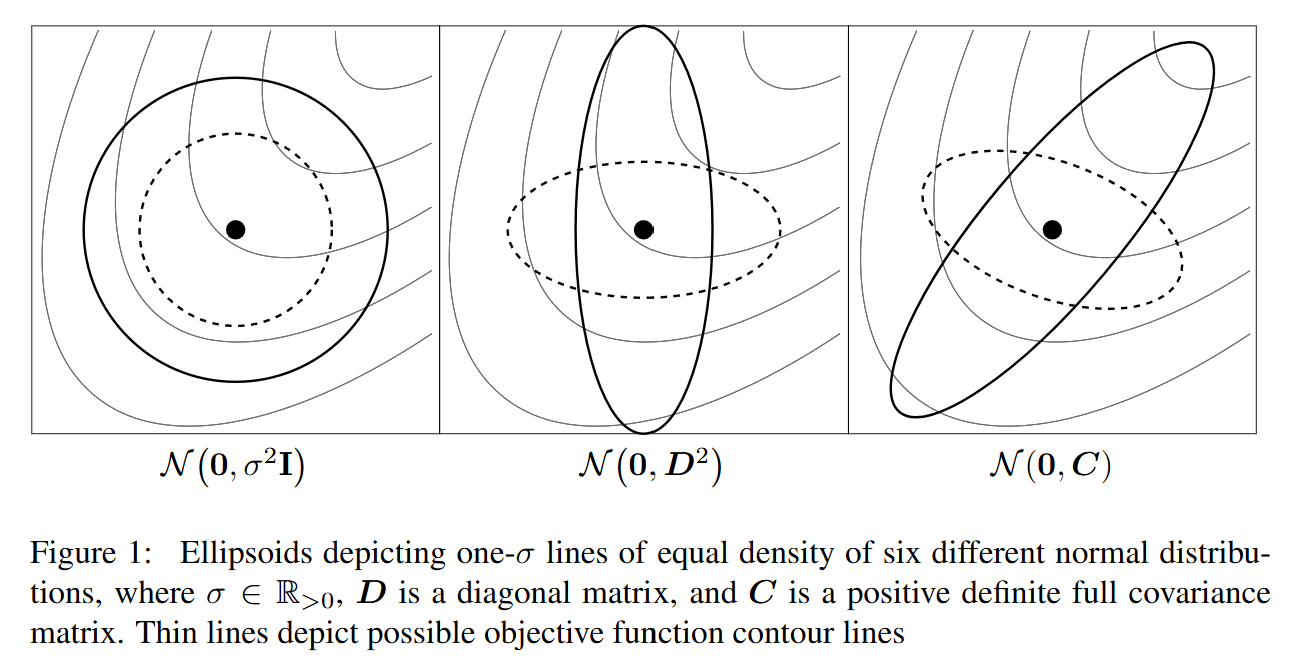

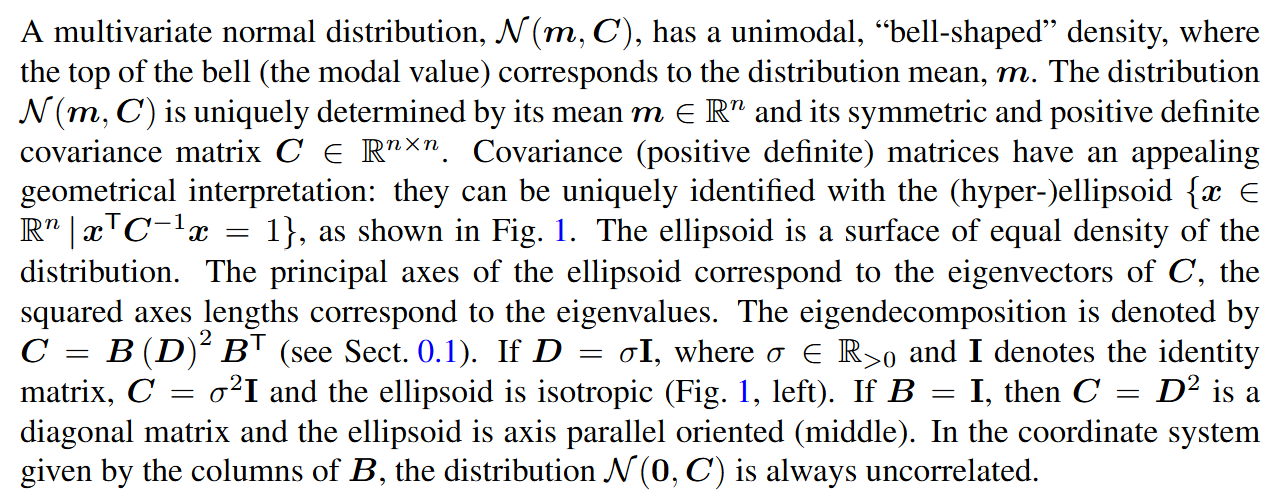

In [10]:
file_path_pic_2 = '/content/drive/MyDrive/Hình cho CMA-ES/assets/2.png'
file_path_pic_3 = '/content/drive/MyDrive/Hình cho CMA-ES/assets/3.png'
display(Image(filename=file_path_pic_2, width=600))
display(Image(filename=file_path_pic_3, width=600))

Trong đoạn này thì tác giả giải thích về:

1. Phân phối chuẩn đa biến có mật độ hình bell-shaved với một đỉnh duy nhất, đỉnh chuông thì tương ứng với mean $m$. Phân phối này được xác định hoàn toàn bởi trung bình $m$ và ma trận hiệp phương sai $C$ (đối xứng và xác định dương).
2. Ma trận $C$ là một khối hyper-ellipsoid được xác định bởi phương trình

$$
\{\mathbf{x} \in \mathcal{R}^n | \text{ }  \mathbf{x}^TC^{-1}\mathbf{x} = 1\}
$$

bề mặt khối elip là tập hợp các điểm có cùng một mức mật độ xác suất.

1. Như phân tích về ma trận hiệp phương sai $C$ thì các vector riêng của ma trận này là hướng của các trục chính của khối elip. Các giá trị riêng tương ứng với bình phương độ dài của các trục này (giải thích ở mục câu hỏi 1).
2. Dựa vào công thức $C = BD^2B^T$, ta thấy:
    - Đẳng hướng: Nếu $D = \sigma I$, ta có $C = \sigma^2 I$ → Khối elip được trải ra mọi hướng và tạo thành khối cầu (hình 1 bên trái) (trả lời trong câu hỏi 2)
    - Song song với các trục tọa độ: Nếu ma trận $B = I$ thì $C = D^2$
3. Nếu dùng vector riêng làm trục tọa độ mới hay chuyển sang không gian hệ tọa độ được tạo bởi các cột của $B$ thì phân phối $\mathcal{N}(0, C)$ luôn ở trạng thái không có sự tương quan.

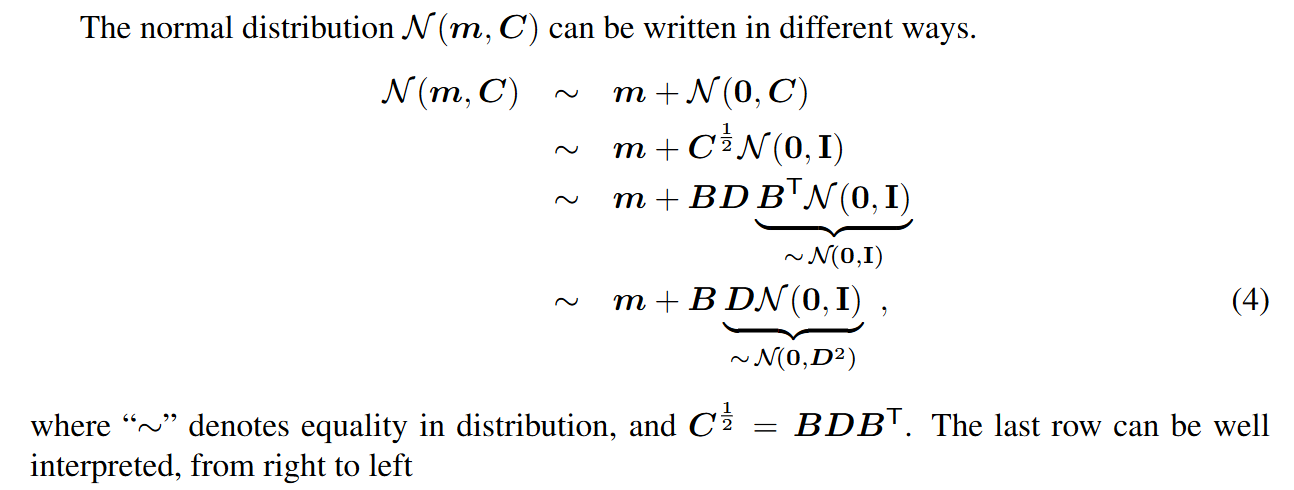

In [12]:
file_path_pic_4 = '/content/drive/MyDrive/Hình cho CMA-ES/assets/4.png'
display(Image(filename=file_path_pic_4, width=600))

Phân tích lần lượt các phép biển đổi:

$$
\mathcal{N}(m, C) \sim m + \mathcal{N}(0, C) \tag{1}
$$

Công thức này có thể hiểu là việc lấy mẫu tại phân phối chuẩn có tâm là $m$ cũng tương đương với việc lấy mẫu tại phân phối chuẩn có tâm = 0 và sau đó dịch chuyển với một vector $m$. Độ phân tán của dữ liệu hay ma trận hiệp phương sai $C$ là không đổi

$$
m + \mathcal{N}(0, C) \sim m + C^{\frac{1}{2}}\mathcal{N}(0, I) \tag{2}
$$

Biến đổi này sẽ phức tạp hơn một tí, đầu tiên thì đi từ lý thuyết sau đây:

Trong lý thuyết xác suất, một phép biến đổi tuyến tính (nhân với ma trận $A$) tác động lên một biến phân phối chuẩn sẽ luôn tạo ra một phân phối chuẩn mới. Tức là nếu ta có

$$
z \sim \mathcal{N}(0, I)
$$

Ta có kết luận $Az \sim \mathcal{N}(0, AA^T)$

Chứng minh:

Ta có $z \sim \mathcal{N}(0, I)$ nên ta có

$$
E[z] = 0 \text{ và } Cov(z) = \mathbb{E}[zz^T] = I
$$

$$
\mathbb{E}[Az] = A\mathbb{E}[z] = A.0 = 0
$$

$$
Cov(Az)=Cov[(Az)(Az)^T] = Cov[A(zz^T)A^T] = ACov(zz^T)A^T = A\mathbb{E}[zz^T]A^T
$$

$$
\Rightarrow Cov(Az) = AIA^T = AA^T
$$

Vậy ta có $Az \sim N(0, AA^T)$.

Áp dụng kết quả trên vào phép biến đổi (2):

$$
C^{\frac{1}{2}}\mathcal{N}(0, I) \sim \mathcal{N}(0, C^{\frac{1}{2}}(C^{\frac{1}{2}})^T) = \mathcal{N}(0, C)
$$

Vậy ta thu được phép biến đổi (2)

Bản chất của phép biến đổi này là để máy tính mô phỏng lại được $\mathcal{N}(0, C)$ ban đầu thông qua một loạt phép biến đổi bằng cách sinh ra nhiễu ban đầu (dạng chuẩn tắc) $\mathcal{N}(0, I)$ (một tập hợp các biến độc lập, có phương sai bằng 1, tạo thành hình cầu). Bản chất của phép nhân ma trận $C^{\frac{1}{2}}$ vào nhiễu dạng chuẩn tắc là để chuyển khối cầu này thành khối elip mang theo thông tin của $C$.

$$
m + C^{\frac{1}{2}}\mathcal{N}(0, I) \sim m + BDB^T\mathcal{N}(0, I) \tag{3}
$$

Ở đây chỉ đơn giản là thế $C = BDB^T$ vào công thức biến đổi (2)

Có chú thích bên dưới của tác giả như sau:

$$
B^T\mathcal{N}(0, I) \sim \mathcal{N}(0, I)
$$

Cũng khá hiển nhiên vì

$$
B^T\mathcal{N}(0, I) \sim \mathcal{N}(0, B^T(B^T)^T) = \mathcal{N}(0, B^TB = I)
$$

Từ đó ta có phép biến đổi số (4) ở block dưới

$$
m + BDB^T\mathcal{N}(0, I)  \sim m + BD\mathcal{N}(0, I)
$$

Ta thấy chú thích khá hiển nhiên sau

$$
D\mathcal{N}(0, I) \sim \mathcal{N}(0, DD^T = D^2)
$$

Tổng kết lại thì ta có như sau:

- Đầu tiên thì ta tạo ra nhiễu chuẩn tắc $\mathcal{N}(0, I)$ có dạng khối cầu
- Sau đó thì nhân phân phối này với ma trận $D$ sẽ biến phân phối có dạng khối cầu này thành phân phối mới có dạng hình elip chỉ mang theo mỗi thông tin về chiều dài của các trục chính của ma trận $C$.
- Sau đó ta xoay hình elip này sao cho trùng với hướng của khối elip tạo bởi phân phối $\mathcal{N}(0, C)$ bằng cách nhân nó với ma trận $B$ để thực hiện biến đổi tuyến tính.
- Cuối cùng thì chỉ cần dịch chuyển phân phối này theo vector $m$ thì ta thu được phân phối ban đầu $\mathcal{N}(m, C)$.

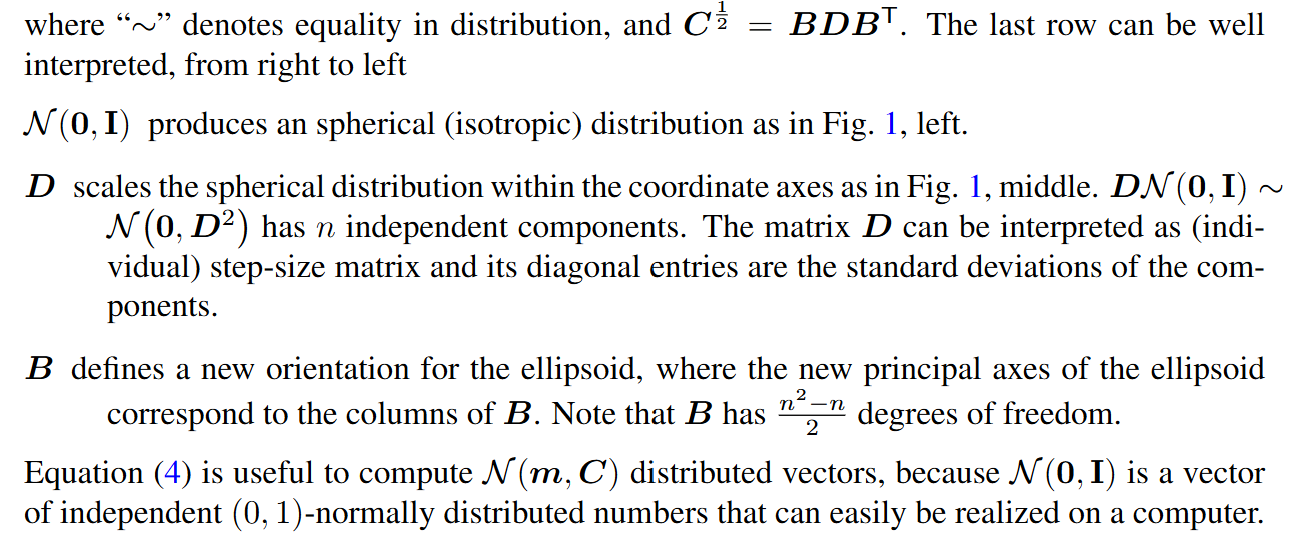

In [13]:
file_path_pic_5 = '/content/drive/MyDrive/Hình cho CMA-ES/assets/5.png'
display(Image(filename=file_path_pic_5, width=600))

Vì sao $B$ có số bậc tự do như vậy?

Bậc tự do (Degrees of Freedom) của một hệ thống được tính bằng tổng số biến số độc lập ban đầu trừ đi số lượng các phương trình ràng buộc toán học tác động lên chúng. Cái này thể hiện tổng các tham số không bị ràng buộc trong một hệ thống, tính như sau:

- Tổng số biến ban đầu: giả sử $B \in \mathcal{R}^n$ thì ta có tổng số biến ban đầu là $n^2$.
- Ràng buộc chuẩn hóa: mỗi cột của $B$ phải có ràng buộc là có độ dài = 1. Mà có $n$ cột nên ta có $n$ phương trình ràng buộc.
- Ràng buộc trực giao: cứ 2 cột trong $B$ thì chúng phải vuông góc với nhau, như vậy thì số lượng ràng buộc là tổ hợp chập 2 của $n$:

$$
\binom{n}{2} = \frac{n(n-1)}{2}
$$

Vậy ta có tổng cộng số lượng ràng buộc là:

$$
n + \frac{n(n-1)}{2} = \frac{n^2 + n}{2}
$$

Số lượng bậc tự do:

$$
n^2 - \frac{n^2 + n}{2} = \frac{n^2 -n}{2}
$$

# Covariance Matrix notes (recall)

Ma trận hiệp phương sai được định nghĩa là ma trận được tạo bởi kỳ vọng tích ngoài của một vector như sau:

$$
C = \mathbb{E}[\mathbf{x} \mathbf{x}^T]
$$

Nếu muốn đo lường mức độ phân tán của tập dữ liệu này dọc theo một hướng cụ thể, ta cần định nghĩa một vector đơn vị $\mathbf{v}$ đại diện cho hướng đó.

Lấy một vector $\mathbf{v}$ bất kỳ sao cho $\mathbf{v}^T\mathbf{v} = 1$

$$
\mathbf{y} = \mathbf{v}^T\mathbf{x}
$$

Tính phương sai của tập dữ liệu:

$$
Var(\mathbf{y}) = \mathbb{E}[y^2] = \mathbb{E}[(\mathbf{v}^T\mathbf{x})^2] = \mathbb{E}[(\mathbf{v}^T\mathbf{x})(\mathbf{v}^T\mathbf{x})] = \mathbb{E}[(\mathbf{v}^T\mathbf{x})(\mathbf{x}^T\mathbf{v})] = \mathbf{v}^T\mathbb{E}[\mathbf{x}\mathbf{x}^T]\mathbf{v}
$$

$$
\Rightarrow Var(\mathbf{y}) = \mathbf{v}^TC\mathbf{v} \tag{1}
$$

Giờ thì giả sử $\mathbf{v}$ là một vector riêng của ma trận hiệp phương sai $C$, thì ta có:

$$
C\mathbf{v} = \lambda\mathbf{v}
$$

Với $\lambda$ là trị riêng của ma trận $C$, thay vào (1) ta có:

$$
Var(\mathbf{y}) = \mathbf{v}^T \lambda \mathbf{v} = \lambda (\mathbf{v}^T\mathbf{v}) = \lambda
$$

Từ đó ta có một kết luận là trị riêng của ma trận hiệp phương sai $C$ chính là phương sai dọc theo trục tọa độ chính của ma trận $C$ này

Ví dụ:

$$
C = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}
$$

Trong ma trận này, các giá trị trên đường chéo (bằng 2) là phương sai dọc theo các trục chuẩn $Ox$ và $Oy$. Các giá trị ngoài đường chéo (bằng 1) thể hiện sự tương quan thuận giữa $x$ và $y$ (dữ liệu có xu hướng nghiêng thành một hình elip).

- **Bước 1: Tìm trị riêng và vector riêng của** $C$
Khi giải phương trình đặc trưng của ma trận $C$, chúng ta thu được:
    - Trị riêng lớn nhất $\lambda_1 = 3$, tương ứng với vector riêng (đã chuẩn hóa có độ dài bằng 1) là hướng $v_1 = \begin{pmatrix} \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{pmatrix}$. Đây là trục chính thứ nhất của elip (hướng phân tán rộng nhất).
    - Trị riêng nhỏ nhất $\lambda_2 = 1$, tương ứng với vector riêng $v_2 = \begin{pmatrix} \frac{1}{\sqrt{2}} \\ -\frac{1}{\sqrt{2}} \end{pmatrix}$. Đây là trục chính thứ hai, vuông góc với $v_1$.
- **Bước 2: Kiểm chứng phương sai dọc theo các trục này**
Như đã chứng minh ở trên, phương sai của dữ liệu khi chiếu lên một hướng $v$ bất kỳ được tính bằng công thức: $\text{Var} = v^T C v$.
- Hãy thử tính phương sai dọc theo hướng của vector riêng $v_1$:

$$
\text{Var}(v_1) = v_1^T C v_1 = \begin{pmatrix} \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \end{pmatrix} \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix} \begin{pmatrix} \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{pmatrix}
$$

Nhân hai ma trận đầu tiên với nhau

$$
\begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix} \begin{pmatrix} \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{pmatrix} = \begin{pmatrix} \frac{2}{\sqrt{2}} + \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} + \frac{2}{\sqrt{2}} \end{pmatrix} = \begin{pmatrix} \frac{3}{\sqrt{2}} \\ \frac{3}{\sqrt{2}} \end{pmatrix}
$$

Tiếp tục nhân vô hướng với vector chuyển vị:

$$
\text{Var}(v_1) = \begin{pmatrix} \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \end{pmatrix} \begin{pmatrix} \frac{3}{\sqrt{2}} \\ \frac{3}{\sqrt{2}} \end{pmatrix} = \left(\frac{1}{\sqrt{2}} \times \frac{3}{\sqrt{2}}\right) + \left(\frac{1}{\sqrt{2}} \times \frac{3}{\sqrt{2}}\right) = \frac{3}{2} + \frac{3}{2} = 3
$$

Kết quả ra bằng $3$, tức là **bằng đúng trị riêng** $\lambda_1$

Nếu làm phép tính tương tự cho $v_2$: Kết quả ra bằng 1, **bằng đúng trị riêng** $\lambda_2$.

$$
\text{Var}(v_2) = v_2^T C v_2 = \begin{pmatrix} \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} \end{pmatrix} \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix} \begin{pmatrix} \frac{1}{\sqrt{2}} \\ -\frac{1}{\sqrt{2}} \end{pmatrix} = \begin{pmatrix} \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} \end{pmatrix} \begin{pmatrix} \frac{1}{\sqrt{2}} \\ -\frac{1}{\sqrt{2}} \end{pmatrix} = \frac{1}{2} + \frac{1}{2} = 1
$$

# Explanation for $D^2$ in Eigendecomposition section

Lý do chính nhất khi sử dụng $D^2%$ thay vì D thông thường là trong cma-es, ma trận $C$ được xem là ma trận hiệp phương sai ($C = \mathbb{E}[xx^T]$). Và các giá trị riêng của ma trận hiệp phương sai chính là phương sai dọc theo trục tọa độ chính của ma trận $C$. Khi lấy căn bậc hai thì sẽ cho ra độ lệch chuẩn ($d_i = \sqrt\lambda_i = \sigma_{i}$), do đó thì ma trận $D$ là ma trận chứa thông tin về độ lệch chuẩn này.

- **Cơ chế lấy mẫu (Sampling):** Thuật toán sinh ra các cá thể mới từ phân phối chuẩn đa biến
$\mathcal{N}(m, C)$. Để biến đổi một vector nhiễu ngẫu nhiên chuẩn hóa $z \sim \mathcal{N}(0, I)$ thành một vector tuân theo phân phối có hiệp phương sai $C$, thuật toán cần sử dụng "căn bậc hai" của ma trận $C$

$$
C = B D^2 B^T = (B D)(B D)^T
$$

- **Công thức sinh cá thể:** Nhờ định nghĩa sẵn $D$, công thức đột biến (mutation) để sinh ra cá thể mới $x$ được viết cực kỳ gọn gàng và dễ dàng vector hóa khi tính toán bằng các thư viện như NumPy

$$
x = m + \sigma B D z
$$

Trong đó:

1.  $z$: Sinh các giá trị nhiễu độc lập.
2. $D$: Scale (kéo giãn/co lại) nhiễu này theo độ lệch chuẩn tương ứng của từng trục chính.
3. $B$: Xoay các trục đã scale về đúng hướng trong hệ tọa độ gốc.

# Câu hỏi 1

Vì sao các trị riêng tương ứng với bình phương độ dài của các trục hình elip?

Recall một chút về kiến thức hình elip hồi ở phổ thông:

$$
\frac{x^2}{a^2} + \frac{y^2}{b^2} = 1
$$

Với $a$ và $b$ là độ dài bán trục của khối elip.

Đi từ định nghĩa

$$
\mathbf{x}^TC^{-1}\mathbf{x} = 1
$$

mà ta lại có

$$
C^{-1} = BD^{-2}B^T
$$

Suy ra,

$$
\mathbf{x}^T (B D^{-2} B^T) \mathbf{x} = 1
$$

Gộp cụm $B^T\mathbf{x}$ lại và đặt $\mathbf{y} = B^T\mathbf{x}$. Về mặt hình học, $\mathbf{y}$ là tọa độ của điểm $\mathbf{x}$ sau khi đã xoay hệ quy chiếu sao cho các trục tọa độ trùng khớp với các vector riêng (cột của $B$). Phương trình trở thành:

$$
\mathbf{y}^TD^{-2}\mathbf{y} = 1
$$

Khai triển vế trái:

$$
\frac{y_1^2}{d_1^2} + \frac{y_2^2}{d_2^2} + \dots + \frac{y_n^2}{d_n^2} = 1
$$

Nhìn lại công thức của khối elip này thì rõ ràng các trị riêng $d_i^2 = \lambda_i$ của ma trận $C$ chính là bình phương độ dài của các trục chính của khối elip

# Câu hỏi 2

Vì sao hình elip trong các trường hợp lại như vậy?

## Trường hợp đẳng hướng Hình cầu

Có: $D = \sigma I$, có nghĩa là mọi trị riêng của ma trận $C$ đều bằng nhau

$$
\lambda_1 = \lambda_2 = \dots = \sigma^2
$$

Thay vào lại trong $C$, ta được:

$$
C = B(\sigma^2I)B^T = \sigma^2BB^T = \sigma^2 I
$$

Dẫn tới phương trình elip trong câu hỏi 1 sẽ trở thành:

$$
\frac{y_1^2}{d_1^2} + \frac{y_2^2}{d_2^2} + \dots + \frac{y_n^2}{d_n^2} = 1 \Rightarrow y_1^2 + y_2^2 + \dots = \sigma^2
$$

Đây là phương trình của một khối cầu.

## Trường hợp song song trục tọa độ

Ta có $B = I$, mà ma trận $B$ là ma trận chứa vector riêng tương ứng với các trị riêng có được từ $C$ và các vector riêng này quyết định hướng xoay của hình elip

Dẫn tới nếu $B = I$ thì các vector riêng là các trục tọa độ gốc $(1, 0, \dots, 0)$, $(0, 1, \dots, 0)$,..

Và phương trình của $C$ được biểu diễn lại như sau:

$$
C = ID^2I = D^2
$$

Hay nói cách khác thì nếu ta đưa các trục chính của khối elip này sao cho song song với trục tọa độ thì ta thu được ma trận hiệp phương sai $C = D^2$. Và vì ma trận $D^2$ là ma trận đường chéo nên ngoại trừ các giá trị trên đường chéo chính thì các giá trị còn lại đều bằng 0 mà bản thân các giá trị ngoài đường chéo chính đều là hiệp phương sai của các biến $x_1, x_2, \dots, x_n$ nên chắc chắn là các biến này không có tương quan tuyến tính với nhau.

Đó là lý do vì sao khi ta thay đổi các giá trị $x_1, x_2, \dots, x_n$ trong hình (1) (ở giữa) thì sẽ không khiến elip bị xoay xiên đi mà chỉ khiến chúng bị thay đổi về chiều dài của trục chính của khối elip.

## Không gian tương quan

Giả sử $\mathbf{x}$ là một vector dữ liệu gốc tuân theo phân phối $\mathcal{N}(0, C)$.
Khi chuyển sang hệ tọa độ mới tạo bởi các cột của $B$, tọa độ mới của điểm dữ liệu (gọi là $y$) được tính bằng phép nhân tọa độ cũ với ma trận nghịch đảo của $B$. Vì $B$ là ma trận trực giao, $B^{-1} = B^T$, nên phép biến đổi là:

$$
y = B^T x
$$

Ta tính ma trận hiệp phương sai mới của $y$, ký hiệu là $C_y$:

$$
C_y = \mathbb{E}[y y^T]
$$

Thay $y = B^T x$:

$$
C_y = \mathbb{E}[(B^T x)(B^T x)^T] = \mathbb{E}[B^T x x^T (B^T)^T] = \mathbb{E}[B^T x x^T B]
\Rightarrow C_y = B^T \mathbb{E}[x x^T] B
$$

Vì $\mathbb{E}[x x^T]$ chính là định nghĩa của ma trận hiệp phương sai gốc $C$, ta có:

$$
C_y = B^T C B
$$

Bây giờ, thay thế phân tích $C = B D^2 B^T$ vào phương trình:

$$
C_y = B^T (B D^2 B^T) B
$$

Nhóm các ma trận lại:

$$
C_y = (B^T B) D^2 (B^T B)
$$

Vì $B$ là ma trận trực giao tạo nên từ các vector riêng, ta luôn có $B^T B = I$. Do đó phương trình triệt tiêu hoàn toàn $B$:

$$
C_y = I D^2 I = D^2
$$

**Ý nghĩa kết quả**
Kết quả $C_y = D^2$ cho thấy ma trận hiệp phương sai trong không gian mới chính là ma trận $D^2$. Vì $D^2$ thuần túy là một ma trận đường chéo (các phần tử ngoài đường chéo bằng 0), hiệp phương sai chéo giữa các biến tọa độ mới $y_1, y_2, \dots, y_n$ là bằng 0 (có thể kết luận như trên là chúng không tương quan tuyến tính lẫn nhau).

Về mặt hình học, khối elip dữ liệu ban đầu có thể nằm nghiêng chéo trong không gian (việc nằm nghiêng này là do các biến gốc có tương quan với nhau). Khi ta xoay hệ trục tọa độ để trùng khớp hoàn toàn với các trục chính của elip (cột của ma trận $B$), ta sẽ thấy khối elip không còn xiên nữa. Khi trục của elip song song với trục tọa độ, sự thay đổi trên trục này không ảnh hưởng đến trục kia, tạo ra không gian dữ liệu hoàn toàn không tương quan (đối với phân phối chuẩn đa biến thì ta có thể nói chúng độc lập với nhau).

# CMA-ES Python Implementation

# References
[CMA-ES](https://arxiv.org/pdf/1604.00772)